In [8]:
# Semantic Supervision for W_v: Three Prototypes (LSA, LDA, NMF)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, NMF, PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from gensim import corpora, models
import gensim.downloader as api
import nltk
nltk.download('punkt')

# --- Step 1: Load a Larger Corpus (20 Newsgroups Subset) ---
print("Loading 20 Newsgroups corpus...")
newsgroups = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
corpus = newsgroups.data[:200]  # Limit for speed/demo

# --- Step 2: Load Pretrained Embeddings ---
print("Loading GloVe embeddings...")
glove = api.load("glove-wiki-gigaword-100")  # 100-dim
embedding_dim = 100

# --- Step 3: Preprocess and Vectorize Corpus ---
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(corpus)
vocab = vectorizer.get_feature_names_out()

# --- Step 4: Create Token → Embedding Mapping ---
token_embeddings = {}
for token in vocab:
    if token in glove:
        token_embeddings[token] = glove[token]

filtered_vocab = list(token_embeddings.keys())
filtered_idx = [i for i, word in enumerate(vocab) if word in token_embeddings]
X_filtered = X[:, filtered_idx]
E = np.stack([token_embeddings[word] for word in filtered_vocab])

# --- A. LSA ---
n_components = min(32, X_filtered.shape[1])
print("Training LSA model...")
lsa_model = TruncatedSVD(n_components=n_components)
lsa_topics = lsa_model.fit_transform(X_filtered.T)

# --- B. LDA ---
tokenized = [nltk.word_tokenize(doc.lower()) for doc in corpus]
dictionary = corpora.Dictionary(tokenized)
corpus_bow = [dictionary.doc2bow(text) for text in tokenized]
lda_model = models.LdaModel(corpus=corpus_bow, id2word=dictionary, num_topics=n_components, passes=10)
lda_topics = np.zeros((len(filtered_vocab), n_components))
for i, word in enumerate(filtered_vocab):
    if word in dictionary.token2id:
        topic_dist = lda_model.get_term_topics(dictionary.token2id[word], minimum_probability=0)
        for topic_id, prob in topic_dist:
            lda_topics[i, topic_id] = prob

# --- C. NMF ---
print("Training NMF model...")
nmf_model = NMF(n_components=n_components, init='nndsvd')
nmf_topics = nmf_model.fit_transform(X_filtered.T)

# --- Prepare Tensors ---
E_tensor = torch.tensor(E, dtype=torch.float32)
lsa_tensor = torch.tensor(lsa_topics, dtype=torch.float32)
lda_tensor = torch.tensor(lda_topics, dtype=torch.float32)
nmf_tensor = torch.tensor(nmf_topics, dtype=torch.float32)

# --- Train Projection Matrices ---
def train_projection(E_tensor, target_tensor, name="Wv"):
    print(f"Training {name} to map embeddings to semantic space...")
    W = nn.Linear(embedding_dim, target_tensor.shape[1], bias=False)
    optimizer = torch.optim.Adam(W.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for epoch in range(300):
        optimizer.zero_grad()
        pred = W(E_tensor)
        loss = loss_fn(pred, target_tensor)
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0:
            print(f"{name} Epoch {epoch}, Loss: {loss.item():.4f}")
    return W

Wv_lsa = train_projection(E_tensor, lsa_tensor, name="Wv_lsa")
Wv_lda = train_projection(E_tensor, lda_tensor, name="Wv_lda")
Wv_nmf = train_projection(E_tensor, nmf_tensor, name="Wv_nmf")

[nltk_data] Downloading package punkt to /home/rca2t/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loading 20 Newsgroups corpus...
Loading GloVe embeddings...
Training LSA model...
Training NMF model...
Training Wv_lsa to map embeddings to semantic space...
Wv_lsa Epoch 0, Loss: 851.7451
Wv_lsa Epoch 50, Loss: 844.6647
Wv_lsa Epoch 100, Loss: 838.4740
Wv_lsa Epoch 150, Loss: 832.7058
Wv_lsa Epoch 200, Loss: 827.2980
Wv_lsa Epoch 250, Loss: 822.2097
Training Wv_lda to map embeddings to semantic space...
Wv_lda Epoch 0, Loss: 0.0926
Wv_lda Epoch 50, Loss: 0.0003
Wv_lda Epoch 100, Loss: 0.0000
Wv_lda Epoch 150, Loss: 0.0000
Wv_lda Epoch 200, Loss: 0.0000
Wv_lda Epoch 250, Loss: 0.0000
Training Wv_nmf to map embeddings to semantic space...
Wv_nmf Epoch 0, Loss: 0.3043
Wv_nmf Epoch 50, Loss: 0.1613
Wv_nmf Epoch 100, Loss: 0.1591
Wv_nmf Epoch 150, Loss: 0.1586
Wv_nmf Epoch 200, Loss: 0.1584
Wv_nmf Epoch 250, Loss: 0.1584


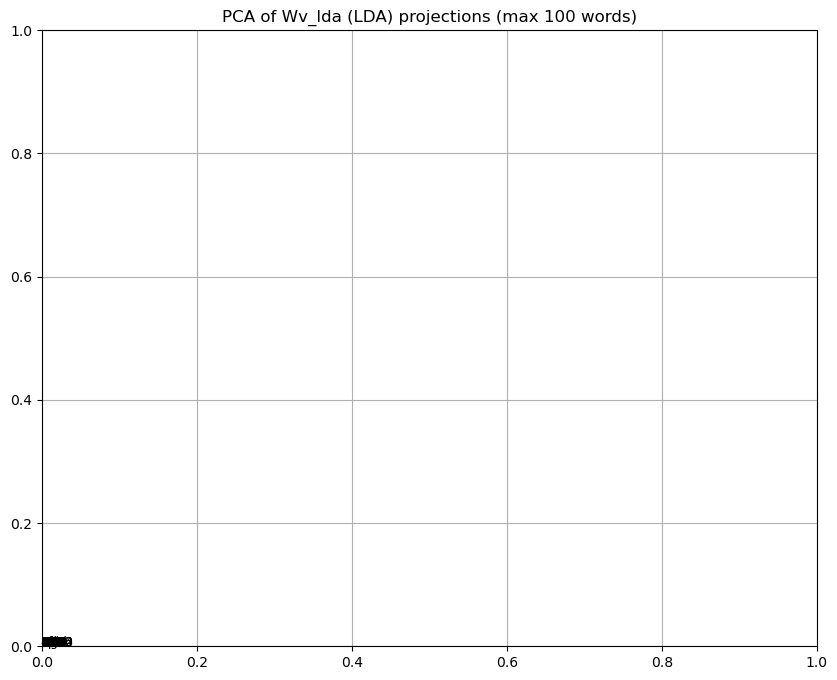

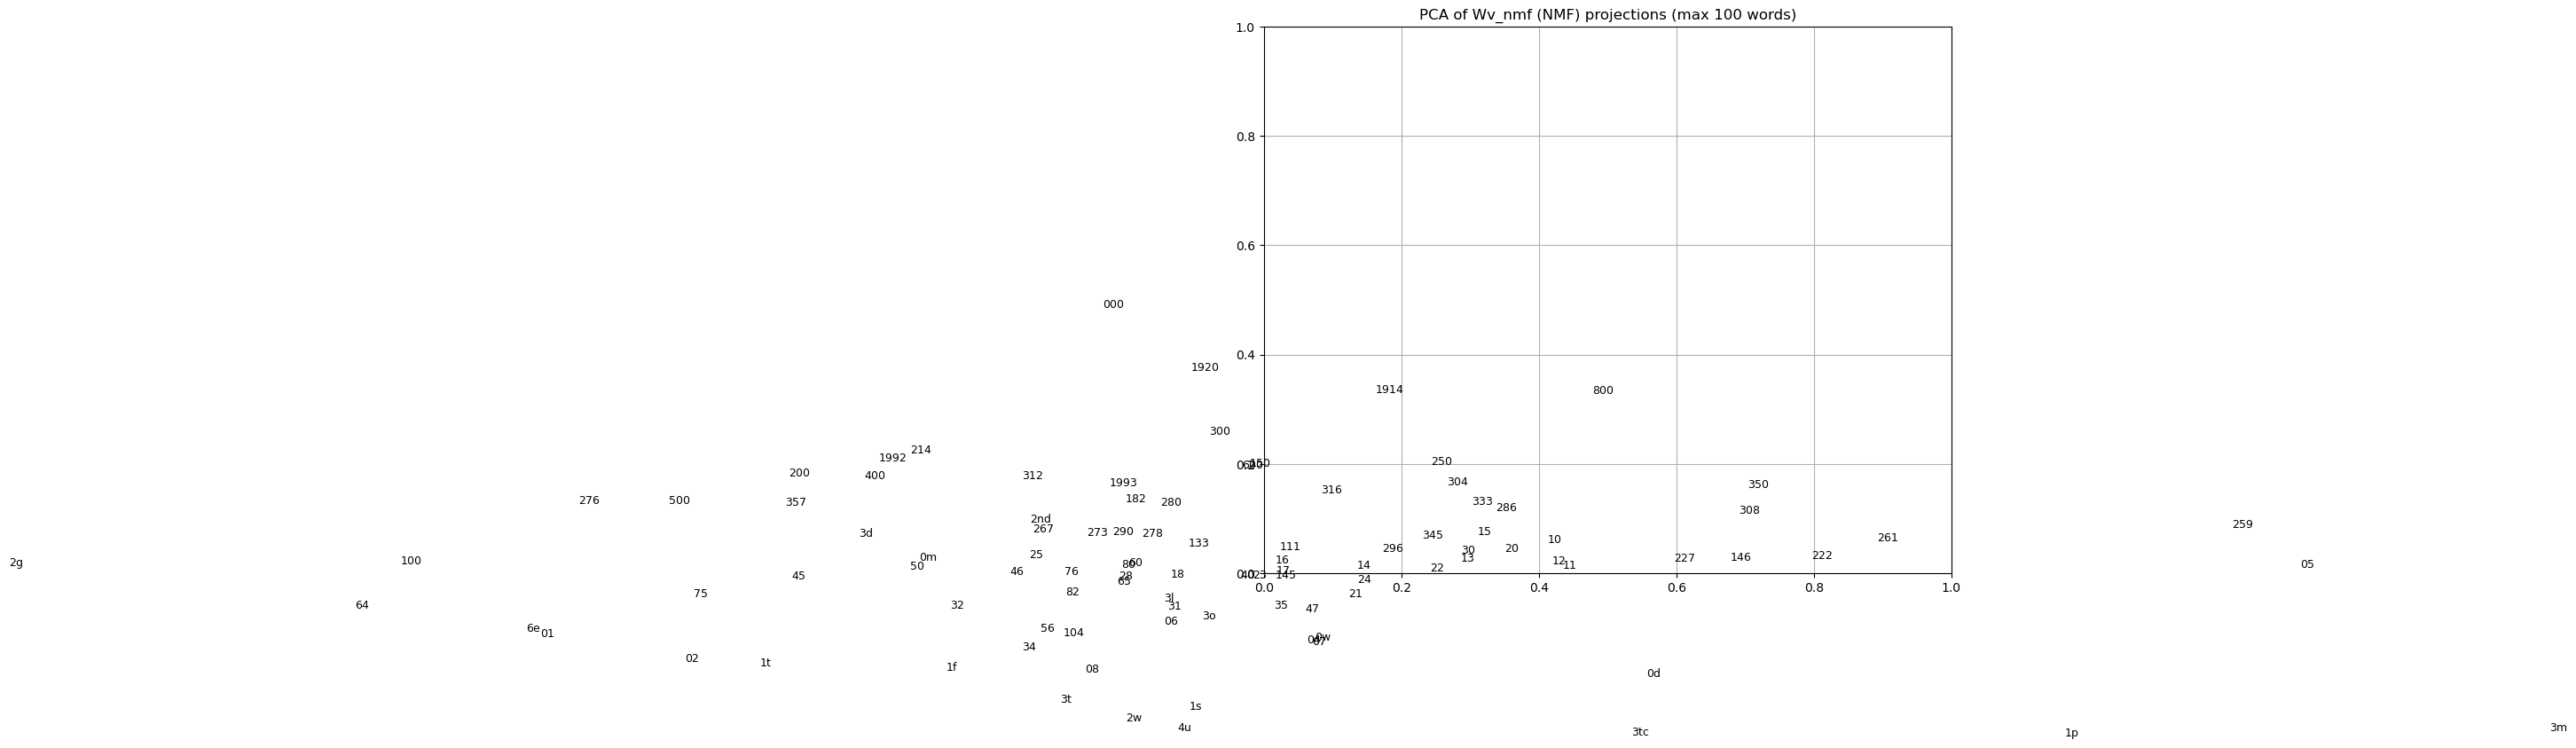

In [11]:
# --- Visualize Projections Using PCA ---
def visualize_projection(W, label="W_v", max_words=100):
    with torch.no_grad():
        projected = W(E_tensor).numpy()
        pca = PCA(n_components=2)
        coords = pca.fit_transform(projected)
        plt.figure(figsize=(10, 8))
        for i, word in enumerate(filtered_vocab[:max_words]):
            plt.text(coords[i, 0], coords[i, 1], word, fontsize=9)
        plt.title(f"PCA of {label} projections (max {max_words} words)")
        plt.grid(True)
        plt.show()

visualize_projection(Wv_lsa, "Wv_lsa (LSA)")
visualize_projection(Wv_lda, "Wv_lda (LDA)")
visualize_projection(Wv_nmf, "Wv_nmf (NMF)")

In [10]:
from sklearn.preprocessing import normalize
lda_topics = normalize(lda_topics, norm='l2')